# Synthetic FAST5

Examining and Analysing synthetic data produced by Squigulator. Creating end to end pipeline for the dataset creation and examining the sampling for reads to figure out how to create the labels and align

In [32]:

from ont_fast5_api.fast5_interface import get_fast5_file

def get_data_from_fast5(fast5_filepath):
    raw_data_arr = []
    read_ids = []
    with get_fast5_file(fast5_filepath, mode="r") as f5:
        for read in f5.get_reads():
            raw_data = read.get_raw_data()
            raw_data_arr.append(raw_data)
            read_ids.append(read.read_id)
    return raw_data_arr, read_ids


fast5_filepath = r"C:\Users\Parv\Doc\HelixWorks\Basecalling\squigulator\slow5tools-v1.1.0\out_signal.fast5"

raw_data_arr, read_ids = get_data_from_fast5(fast5_filepath)

## Extracting Sequence for each Read

In [12]:
fasta_filepath = r"C:\Users\Parv\Doc\HelixWorks\Basecalling\squigulator\sample.fa.txt"
read_sequences = []

with open(fasta_filepath, "r") as f:
    fasta_seq = f.readlines()[1]

In [13]:
for read_id in read_ids:
    split_id = read_id.split('!') # To get the starting and ending character positions for the specific read id
    starting_pos, ending_pos = int(split_id[2]), int(split_id[3])
    read_seq = fasta_seq[starting_pos:ending_pos]
    read_sequences.append(read_seq)
    

In [14]:
len(read_sequences) == len(read_ids) == len(raw_data_arr)

True

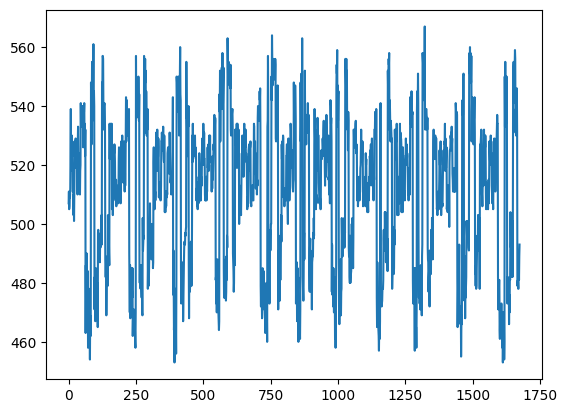

ACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACACACACACAGTAACCAACAC


In [21]:
import matplotlib.pyplot as plt
import numpy as np

smallest_index = 0
smallest_seq_len = np.inf

# Getting smallest sequence
for index, seq in enumerate(read_sequences):
    if len(seq) < smallest_seq_len:
        smallest_index = index
        smallest_seq_len = len(seq)

plt.plot(raw_data_arr[smallest_index])
plt.show()
print(read_sequences[smallest_index])

In [25]:
print(len(raw_data_arr[smallest_index]))
print(len(read_sequences[smallest_index]))

1675
200


### Distribution of values representing one base

In [29]:
import numpy as np

squiggle_per_base = []

for i in range(len(raw_data_arr)):
    squiggle_per_base.append(len(raw_data_arr[i])/len(read_sequences[i]))

squiggle_per_base = np.array(squiggle_per_base)
mean = np.mean(squiggle_per_base)
std = np.std(squiggle_per_base)

9.0341431527063


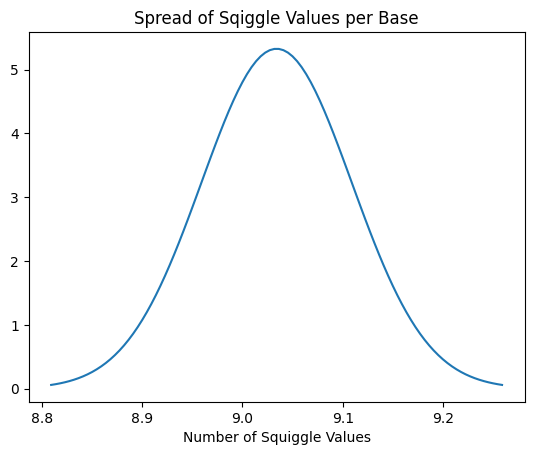

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math

mu = mean
sigma = std
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.title("Spread of Sqiggle Values per Base")
plt.xlabel("Number of Squiggle Values")
plt.show()

### Compare that with Empirical Dataset

## Creating Synthetic Dataset (Squigulator Specific)

1. For choice of motifs and links, len of dataset create seq
2. Create synth.fasta
3. Run Squigulator to create blo5 file
4. Run slo5tools to convert blo5 to f5
5. Get raw data from f5 file
6. Get sequences for the raw data
7. Create Label from sequences
8. Create Dataset 

In [7]:
### Creating Sequence to be simulated

import numpy as np

len_motif = 20
len_link = 0 # To be implemented later
n_motifs = 10

motif_choices = [
    "AGTCTAGCTCGTACGTTCGA",
    "TGGCACTCATCAATCCGTAT",
    "GACTTGCAATCGCTAAGCTA",
    "CTATGAGGTCTGCCTTACAC",
    "AAGTCGTCTCGTTGCATCGA",
    "TCCAGTAGATCGTCAGCTTC",
    "GTACCGAATCTGGTAAGCTA",
    "CGATCATCGCAAGCTTAGAC",
    "ATTCGTCGAACATGCTTCCA",
    "GCTACTCGACTTGAAGCTGA"
]

links = ['']
len_dataset = 100000  # Number of Bases

n_motifs = int(len_dataset/(len_motif + len_link))

base_seq = ""

for i in range(n_motifs):
    motif_choice = np.random.choice(motif_choices)
    # link = links[motif_choices.index(motif_choice)] - To be implemented later
    base_seq += motif_choice 

In [17]:
### Storing sequence in file

base_filepath = r"C:\Users\Parv\Doc\HelixWorks\Basecalling\squigulator\sample.fa.txt"
with open(base_filepath, 'w') as f:
    f.write(f">seq_3782 {len_dataset}bp\n")
    f.write(base_seq)
    f.close()
    

In [ ]:
### Simulating using Squigulator

!pwd

In [11]:
### Moving to slowtools and converting to fast5

In [12]:
### Getting raw from f5

In [13]:
### Getting base seqeuences corresponding to data

In [14]:
### Creating label from sequences

In [15]:
### Creating Dataset